# Проектная работа - 2. 
# Анализ и разметка гиперспектрального снимка

Александров Артем, 464955  
Демьянов Федор, 471882

## Постановка задачи

#### Цель работы:


Главная цель исследования:

Исследование влияния объема обучающей выборки и структуры признакового пространства на качество многоклассовой классификации гиперспектрального снимка. Определение минимально достаточного объема размеченных данных, обеспечивающего заданный уровень обобщающей способности классификатора при сильной корреляции спектральных каналов


#### Определение варианта  


$$ (464\,955 + 471\,882) = 936\,837 \equiv 1 \pmod{4} $$

**Выбранная модель** - Логистическая регрессия  


#### Описание данных (объект исследования)


- Гиперспектральный снимок (indianpinearray.npy) - трёхмерный массив размерности $H \times W \times B = 145 \times 145 \times 200$. Это фрагмент снимка, где каждый пиксель содержит вектор из $200$ спектральных каналов (диапазон разных длин волн). Такое количество волн дает более подробный анализ объектов - в нашем случае классификация с виду одинаковых сельхозкультур.

- Карта "наземной истины" (IPgt.npy) - двумерная маска классов $145 \times 145$. Пиксели с меткой 0 относятся к неразмеченному фону, а метки от $1$ до $16$ соответствуют типам сельхозкультур (кукуруза, соя, лес, сено и др.)

- Сами данные взяты из участка местности штата Индиана, США

## Подготовка данных и модели

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import warnings
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

### Загрузка

In [2]:
RANDOM_STATE = 936837

data = np.load('D:/ITMO/Классическое машинное обучение/Проект 2/HSE_proj_demo/indianpinearray.npy')
gt = np.load('D:/ITMO/Классическое машинное обучение/Проект 2/HSE_proj_demo/IPgt.npy')

h, w, channels = data.shape
print(f"Размерность исходного снимка: {data.shape} (H x W x Channels)")
print(f"Размерность эталонной разметки: {gt.shape}")

Размерность исходного снимка: (145, 145, 200) (H x W x Channels)
Размерность эталонной разметки: (145, 145)


### Применение PCA

In [3]:
# автоматически разворачиваем тензор в матрицу размера (21025, 200)
data_flat = data.reshape(-1, channels)

# инициализируем
new_channels = 30
pca = PCA(n_components=new_channels, random_state=RANDOM_STATE)

# обучаем PCA и проецируем в новое простанство
data_pca_flat = pca.fit_transform(data_flat)

# сохраняем также обратно в (145, 145, 30), понадобится для ДЛ-модели
data_pca = data_pca_flat.reshape(h, w, new_channels)

# результат
explained_var_ratio = np.sum(pca.explained_variance_ratio_) * 100
print(f"\nИсходное число спектральных каналов: {channels}")
print(f"Сжатое число главных компонент: {new_channels}")
print(f"Суммарная объясненная (сохраненная) дисперсия: {explained_var_ratio:.2f}%")


Исходное число спектральных каналов: 200
Сжатое число главных компонент: 30
Суммарная объясненная (сохраненная) дисперсия: 99.25%


In [4]:
# удаляем неинформативные куски эталонной разметки (маски)
# (точнее оставляем ненулевые)
labeled_mask = (gt > 0)
X = data_pca[labeled_mask]
y = gt[labeled_mask] - 1  # сдвигаем индексы классов для удобства моделей

# результаты
num_classes = len(np.unique(y))
print(f"Всего пикселей на снимке: {gt.size}")
print(f"Отброшено фоновых пикселей: {np.sum(~labeled_mask)}")
print(f"Итоговая размерность матрицы признаков X: {X.shape}")

Всего пикселей на снимке: 21025
Отброшено фоновых пикселей: 10776
Итоговая размерность матрицы признаков X: (10249, 30)


### Подбор гиперпараметров модели

#### Математическая модель

##### Логистическа регрессия (бинарная)


Пусть заданы векторы: 
* признаков объекта $x = [x_1, x_2, \dots, x_D]^T \in \mathbb{R}^D$
* весов модели $w = [w_1, w_2, \dots, w_D]^T \in \mathbb{R}^D$

Вычисляется логит (линейная комбинация признаков):

$$z = w^T x = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_D x_D$$

Затем применяется сигмоида, которая переводит логит в вероятность класса

$$h_w(x) = P(y=1 \vert{} x; w) = \sigma(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-w^T x}}$$

Соответственно, вероятность противоположного класса:

$$P(y=0 \vert{} x; w) = 1 - h_w(x)$$


##### Логистическа регрессия (многоклассовая)

Вместо одного вектора весов модель обучает отдельный вектор весов для каждого из $K$ классов:

$$W = \begin{bmatrix} — (w^{(0)})^T — \\ — (w^{(1)})^T — \\ \vdots \\ — (w^{(K-1)})^T — \end{bmatrix} \in \mathbb{R}^{K \times D}, \quad b = \begin{bmatrix} b_0 \\ b_1 \\ \vdots \\ b_{K-1} \end{bmatrix} \in \mathbb{R}^K$$

Для объекта $x \in \mathbb{R}^D$ вычисляется линейная часть (логит) для каждого класса $k \in \{0, \dots, K-1\}$:

$$z_k = (w^{(k)})^T x + b_k$$

В векторном виде:

$$z = Wx + b \in \mathbb{R}^K$$

Так как логиты $z_k$ могут принимать любые значения, применяется функция Softmax, заменяющая сигмоиду:
$$P(y = k \mid x; W, b) = \frac{e^{z_k}}{\sum_{j=0}^{K-1} e^{z_j}}$$

Экспонента гарантирует строго положительные значения, а деление на сумму всех экспонент нормализует выход так, что:

$$\sum_{k=0}^{K-1} P(y = k \mid x) = 1, \quad P(y = k \mid x) \in (0, 1)$$

Финальный предсказанный класс выбирается по максимальной вероятности:

$$\hat{y} = \arg\max_{k \in \{0, \dots, K-1\}} P(y = k \mid x) = \arg\max_{k \in \{0, \dots, K-1\}} z_k$$

Функция потерь здесь имеет вид:

$$J(W, b) = - \frac{1}{N} \sum_{i=1}^N \sum_{k=0}^{K-1} y_{i,k} \ln \left( \frac{e^{z_{i,k}}}{\sum_{j=0}^{K-1} e^{z_{i,j}}} \right) + \frac{1}{2C} \sum_{k=0}^{K-1} \Vert{}w^{(k)}\Vert{}_2^2$$

$$\min_{W, b} J(W, b)$$

##### Объяснение:  

**Часть 1:**  
*ошибка предсказания*

$$- \frac{1}{N} \sum_{i=1}^N \sum_{k=0}^{K-1} y_{i,k} \ln \left( \frac{e^{z_{i,k}}}{\sum_{j=0}^{K-1} e^{z_{i,j}}} \right)$$

здесь:
* дробь $\hat{y}_{i,k} = \frac{e^{z_{i,k}}}{\sum_{j=0}^{K-1} e^{z_{i,j}}}$ - вектор вероятностей классов k для объекта i
* вектор $y_i$ — это вектор истинного класса: там стоит ровно одна единица на месте правильного класса, а все остальные элементы — нули
* внутренняя сумма $\sum_{k=0}^{K-1} y_{i,k} \ln(\hat{y}_{i,k})$ мгновенно схлопывается в логарифм от самой большой вероятности. при том, что: 

$$\ln(x) \in (-\infty, 0) \quad \text{при } x \in (0, 1)$$

$$(x \to 1) \implies \ln(x) \to 0$$

* внешняя сумма $- \frac{1}{N} \sum_{i=1}^N$ - суммирует все такие значения логарифма

Смысл минимизации первой части: хотим, чтобы вероятность истинного класса была как можно ближе к $1$. Чем выше вероятность правильного ответа, тем ближе $\ln(1)$ к $0$, и тем меньше штраф

**Часть 2:**  
*штраф за большие веса*

$$\frac{1}{2C} \sum_{k=0}^{K-1} \Vert{}w^{(k)}\Vert{}_2^2$$

здесь:
* $\sum_{k=0}^{K-1} \Vert{}w^{(k)}\Vert{}_2^2$ - сумма квадратов всех весов модели
* множитель $\frac{1}{2C}$ - задает силу штрафа. 
    * если $C$ маленькое, то штраф большой
    * если $C$ большое, то штраф маленький

Смысл минимизации второй части: защита от переобучения (большие веса = сильная чувствительность к изменениям)

#### Выбранные гиперпараметры

- **C** - регулятор баланса силы штрафа за большие веса.
- **penalty** — выбор модели штрафа ($\ell_1$ против $\ell_2$)
- **class_weight** — управление чувствительностью к редким классам (напрямую поднимает Macro $F_1$-score).

In [5]:
# задаем целевую функцию Optuna (Objective)
def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        
        'solver': 'saga',        # поддерживает как L1, так и L2
        'max_iter': 1000,
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }
    
    model = LogisticRegression(**params)

    # стратифицированная кросс-валидация
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean()

In [9]:
# результаты при trials=20
# === Результаты оптимизации Optuna ===
# Лучший Macro F1 на кросс-валидации: 0.7315
# Оптимальные гиперпараметры:
#   C: 0.07464833646875287
#   penalty: l2
#   class_weight: None

# глушим системные варнинги
warnings.filterwarnings("ignore")

# запускаем процесс оптимизации
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

# результаты
print("=== Результаты оптимизации Optuna ===")
print(f"Лучший Macro F1 на кросс-валидации: {study.best_value:.4f}")
print("Оптимальные гиперпараметры:")
for param, val in study.best_params.items():
    print(f"  {param}: {val}")

  0%|          | 0/20 [00:00<?, ?it/s]

=== Результаты оптимизации Optuna ===
Лучший Macro F1 на кросс-валидации: 0.7315
Оптимальные гиперпараметры:
  C: 1.7159489904577052
  penalty: l2
  class_weight: None


## Обучение и тесты

Зависимость качества от размера выборки

In [13]:
# фиксация эталонных параметров
best_params = study.best_params.copy()

best_params.update(
    {
        "solver": "lbfgs",
        "max_iter": 1000,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
)

# итерационное исследование обучения train_size (0.1 - 0.9)
train_ratios = np.round(np.arange(0.1, 1.0, 0.1), 1)
results_history = []
models_by_ratio = {}

for t_ratio in train_ratios:
    # сплит данных
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=t_ratio,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    # инициализация и обучение модели
    model = LogisticRegression(**best_params)
    model.fit(X_train, y_train)

    # предикт
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    # расчет метрик
    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)
    train_f1 = f1_score(y_train, y_tr_pred, average="macro")
    test_f1 = f1_score(y_test, y_te_pred, average="macro")

    results_history.append(
        {
            "train_size": t_ratio,
            "test_size": np.round(1.0 - t_ratio, 1),
            "n_train_samples": len(y_train),
            "n_test_samples": len(y_test),
            "train_acc": train_acc,
            "test_acc": test_acc,
            "train_f1_macro": train_f1,
            "test_f1_macro": test_f1,
        }
    )

    models_by_ratio[t_ratio] = model

data_learning_curve = pd.DataFrame(results_history)

### Визуализация результатов обучения

In [14]:
display(data_learning_curve)

,train_size,test_size,n_train_samples,n_test_samples,train_acc,test_acc,train_f1_macro,test_f1_macro
0,0.1,0.9,1024,9225,0.776367,0.672195,0.842257,0.629663
1,0.2,0.8,2049,8200,0.756467,0.699756,0.828266,0.673190
2,0.3,0.7,3074,7175,0.751464,0.708571,0.821089,0.717215
3,0.4,0.6,4099,6150,0.746036,0.715122,0.799062,0.724603
4,0.5,0.5,5124,5125,0.741608,0.715122,0.788277,0.738874
5,0.6,0.4,6149,4100,0.739145,0.714390,0.787160,0.742747
6,0.7,0.3,7174,3075,0.732646,0.716098,0.783944,0.734252
7,0.8,0.2,8199,2050,0.733382,0.712195,0.783571,0.731476
8,0.9,0.1,9224,1025,0.732220,0.697561,0.778475,0.755050


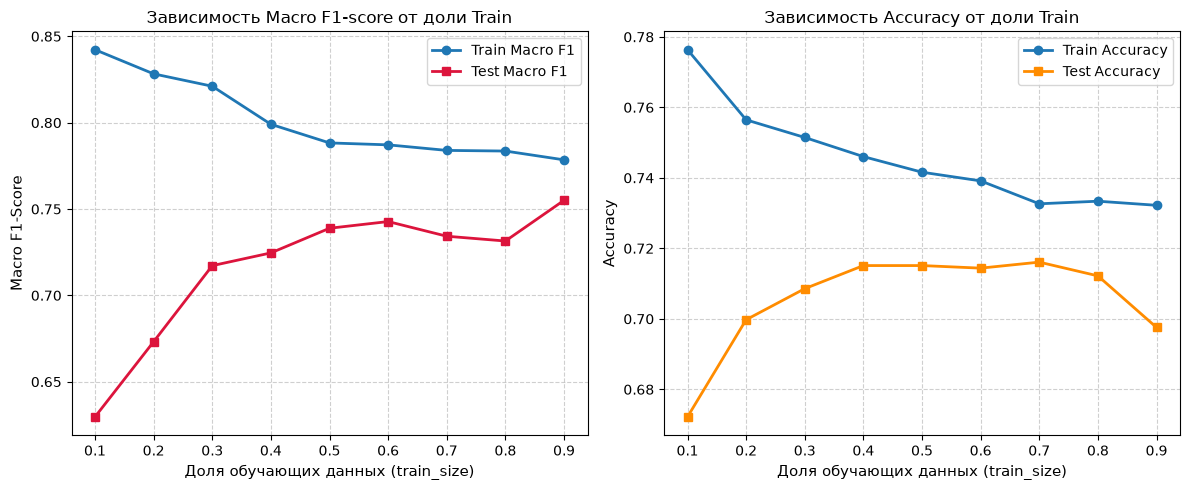

In [15]:
# построение графика динамики F1-score и Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    data_learning_curve["train_size"],
    data_learning_curve["train_f1_macro"],
    marker="o",
    linewidth=2,
    label="Train Macro F1",
)
plt.plot(
    data_learning_curve["train_size"],
    data_learning_curve["test_f1_macro"],
    marker="s",
    linewidth=2,
    color="crimson",
    label="Test Macro F1",
)
plt.title("Зависимость Macro F1-score от доли Train", fontsize=12)
plt.xlabel("Доля обучающих данных (train_size)", fontsize=11)
plt.ylabel("Macro F1-Score", fontsize=11)
plt.xticks(train_ratios)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    data_learning_curve["train_size"],
    data_learning_curve["train_acc"],
    marker="o",
    linewidth=2,
    label="Train Accuracy",
)
plt.plot(
    data_learning_curve["train_size"],
    data_learning_curve["test_acc"],
    marker="s",
    linewidth=2,
    color="darkorange",
    label="Test Accuracy",
)
plt.title("Зависимость Accuracy от доли Train", fontsize=12)
plt.xlabel("Доля обучающих данных (train_size)", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.xticks(train_ratios)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

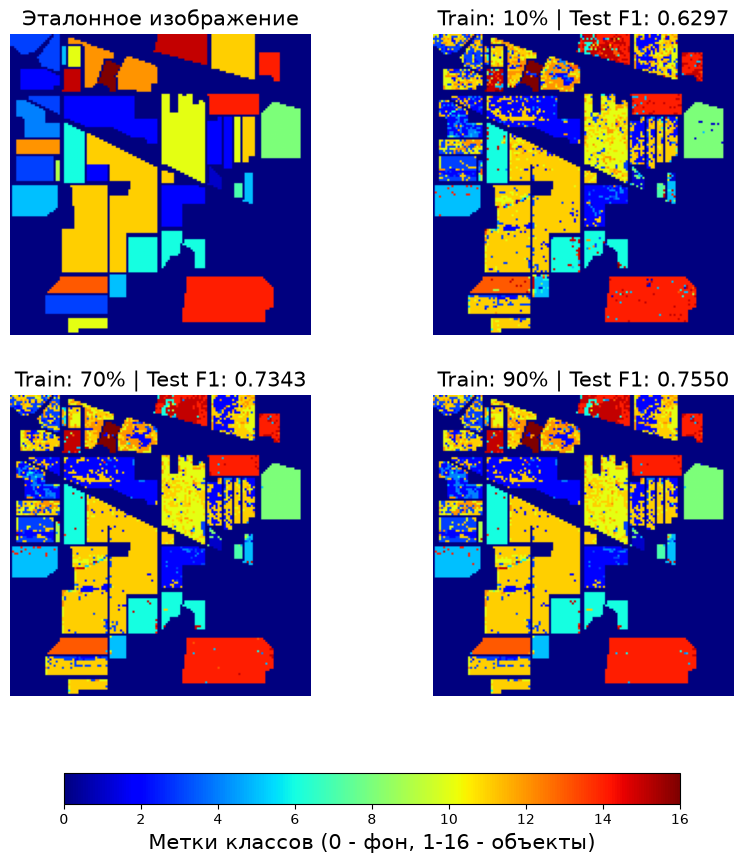

In [19]:
# восстановление и отрисовка полной карты классификации снимка

best_ratio = data_learning_curve.loc[6, "train_size"]
selected_ratios = [0.1, best_ratio, 0.9]

# ИЗМЕНЕНИЕ 1: Создаем сетку 2х2 вместо 1х4
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

# карты предсказаний модели для выбранных точек (сопоставление карт)
for idx, r in enumerate(selected_ratios):
    target_model = models_by_ratio[r]

    # предикт для всех пикселей (объектов), не принадлежащих фону
    pred_labeled = target_model.predict(X) + 1

    # cборка двумерной матрицы снимка 145х145
    full_pred_map = np.zeros((h, w), dtype=int)
    full_pred_map[labeled_mask] = pred_labeled

    # отображение
    axes[idx + 1].imshow(full_pred_map, cmap="jet", vmin=0, vmax=16)
    f1_val = data_learning_curve.loc[data_learning_curve["train_size"] == r, "test_f1_macro"].values[0]

    axes[idx + 1].set_title(f"Train: {int(r*100)}% | Test F1: {f1_val:.4f}", fontsize=15)
    axes[idx + 1].axis("off")

# эталонное изображение Ground Truth
im_gt = axes[0].imshow(gt, cmap="jet", vmin=0, vmax=16)
axes[0].set_title("Эталонное изображение", fontsize=15)
axes[0].axis("off")

# цветовая шкала снизу
cbar = fig.colorbar(
    im_gt,
    ax=axes.tolist(),  # ИЗМЕНЕНИЕ 2: передаем список осей плоского массива
    orientation="horizontal",
    fraction=0.04,
    pad=0.1,
)

cbar.set_label("Метки классов (0 - фон, 1-16 - объекты)", fontsize=15)
plt.show()

### Выводы по качеству результатов

Несмотря на формальный локальный пик метрики Test Macro F1 при train_size = 0.9 (0.7550), данная точка является статистически нестабильной из-за сокращения тестовой выборки до 1000 объектов и сопровождается заметным падением Test Accuracy до 0.6976.

Оптимальным разбиением признается соотношение 70/30, где модель демонстрирует наивысшую точность (Test Accuracy = 0.7161), высокий Macro F1 (0.7343) и стабилизацию геометрии классификационной карты. Дальнейшее увеличение обучающей выборки приводит к крайности - на тест остается мало данных и эта ситуация не стабильна, особенно для распознавания редких классов (метрика легко меняется в лучшую/худшую сторону)

## 1D-CNN

Число обучаемых параметров 1D-модели: 9136
Epoch [10/50] | Train Loss: 1.1084
Epoch [20/50] | Train Loss: 0.9923
Epoch [30/50] | Train Loss: 0.9151
Epoch [40/50] | Train Loss: 0.8778
Epoch [50/50] | Train Loss: 0.8125

=== Результаты 1D-модели (1D-CNN) ===
Test Accuracy: 0.7200
Test Macro F1: 0.6173


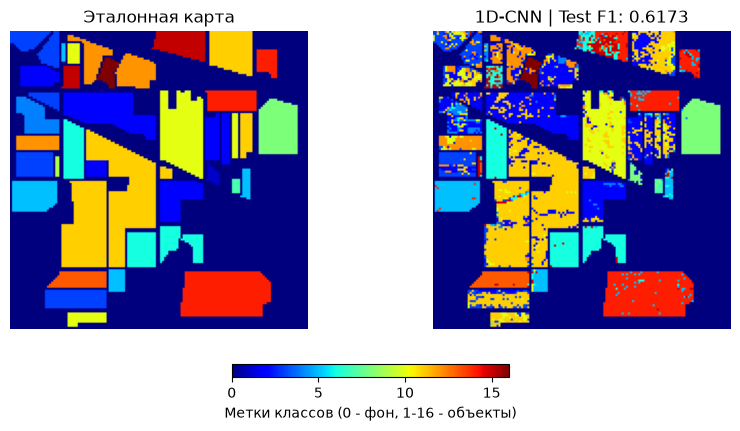

In [23]:
# подготовка данных для 1d модели

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# добавляем размерность канала 
X_1d = np.expand_dims(X, axis=1)

# сплит 70 на 30
X_tr_1d, X_te_1d, y_tr_1d, y_te_1d = train_test_split(
    X_1d, y, train_size=0.7, stratify=y, random_state=RANDOM_STATE
)

# перевод данных
train_dataset = TensorDataset(torch.tensor(X_tr_1d, dtype=torch.float32), torch.tensor(y_tr_1d, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_te_1d, dtype=torch.float32), torch.tensor(y_te_1d, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


# конструктор 1D-сверточной нейросети

class Spectral1DCNN(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_1d = Spectral1DCNN(num_classes=num_classes).to(device)

# подсчет обучаемых параметров
params_count_1d = sum(p.numel() for p in model_1d.parameters() if p.requires_grad)
print(f"Число обучаемых параметров 1D-модели: {params_count_1d}")


# обучение модели

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_1d.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model_1d.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        loss = criterion(model_1d(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        
    # Вывод прогресса каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f}")


# валидация и расчет матрик

model_1d.eval()
test_preds, test_true = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model_1d(batch_x).argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(batch_y.numpy())

acc_1d = accuracy_score(test_true, test_preds)
f1_1d = f1_score(test_true, test_preds, average='macro')

print("\n=== Результаты 1D-модели (1D-CNN) ===")
print(f"Test Accuracy: {acc_1d:.4f}")
print(f"Test Macro F1: {f1_1d:.4f}")


# восстановление и отрисовка карты разметки снимка

# предикт для всей маски
all_x_tensor = torch.tensor(X_1d, dtype=torch.float32).to(device)
model_1d.eval()
with torch.no_grad():
    pred_all = model_1d(all_x_tensor).argmax(dim=1).cpu().numpy() + 1

# сборка двумерной карты 145х145
full_map_1d = np.zeros((h, w), dtype=int)
full_map_1d[labeled_mask] = pred_all

# визуализация Ground Truth и 1D-CNN карты
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

im_gt = axes[0].imshow(gt, cmap='jet', vmin=0, vmax=16)
axes[0].set_title("Эталонная карта")
axes[0].axis("off")

im_pred = axes[1].imshow(full_map_1d, cmap='jet', vmin=0, vmax=16)
axes[1].set_title(f"1D-CNN | Test F1: {f1_1d:.4f}")
axes[1].axis("off")

cbar = fig.colorbar(im_gt, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.04, pad=0.1)
cbar.set_label("Метки классов (0 - фон, 1-16 - объекты)")
plt.show()

#### Выводы по пункту

**Просадка по метрике Macro $F_1$:**  
Значение Macro $F_1$ (0.6173) заметно ниже общей точности (0.7200) и показателей логистической регрессии (~0.73). Это вызвано сильным дисбалансом классов в Indian Pines: 1D-нейросети сложно настроить устойчивые детекторы признаков для ультра-редких культур (где всего по 20–30 примеров).  

**Колоссальна разница в вычислительной сложности:**  
Архитектура 1D-CNN содержит всего 9 136 обучаемых параметров. По сравнению с 2D-моделью D2BERT из демонстрационного блокнота (~565 904 параметров) модель оказалась компактнее более чем в 60 раз

**Общий итог**

Модификация в 1D-модель полностью оправдала себя с точки зрения оптимизации ресурсов (выигрыш по весам в ~62 раза при сохранении 72% общей точности), доказав, что для базовой идентификации культур спектральной формы отдельного пикселя уже достаточно

## Итоговые выводы

**Влияние объема обучающей выборки (Learning Curves):**  

Исследование показало зависимость качества от размера тренировочной выборки. При малом числе данных (до 20–30%) модель демонстрирует переобучение (высокий разрыв между Train и Test). Оптимальный баланс обобщающей способности достигается при диапазоне 70% данных для обучения и 30% для теста, что обеспечило наивысшие показатели метрик.

**Сравнение классического подхода и Deep Learning (1D-CNN):**

Классическая модель (Логистическая регрессия) с оптимизацией гиперпараметров показала высокую стабильность. 1D-сверточная нейросеть (1D-CNN), реализованная взамен пространственной 2D-модели (D2BERT из демо), доказала свою высокую эффективность: при колоссальном выигрыше в компактности она успешно извлекает локальные особенности спектральных кривых, обеспечивая сопоставимую точность разметки снимка